In [0]:
!pip install nltk spacy scikit-learn gensim datasets matplotlib seaborn
!python -m spacy download en_core_web_sm
!pip install datasets==2.21.0

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 112.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import re
import nltk
import spacy
import numpy as np
import pandas as pd

from datasets import load_dataset
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-4ec7f7dc-a217-43bf-82aa-54/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [0]:
from datasets import load_dataset

dataset = load_dataset("imdb")

df = pd.DataFrame(dataset['train'][:2000])  # sample for performance
df = df[['text']]

df.head()

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:56: UserWarning: The cache_dir for this dataset is /tmp/.hf.data.cache, which is not a persistent path.Therefore, if/when the cluster restarts, the downloaded dataset will be lost.The persistent storage options for this workspace/cluster config are: [UC Volumes].Please update either `cache_dir` or the environment variable `HF_DATASETS_CACHE`to be under one of the following root directories: ['/Volumes/']
  warnings.warn(warning_message)
/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:24: UserWarning: During large dataset downloads, there could be multiple progress bar widgets that can cause performance issues for your notebook or browser. To avoid these issues, use `datasets.utils.logging.disable_progress_bar()` to turn off the progress bars.
  warnings.warn(


,text
0,I rented I AM CURIOUS-YELLOW from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten..."
2,If only to avoid making this type of film in t...
3,This film was probably inspired by Godard's Ma...
4,"Oh, brother...after hearing about this ridicul..."


In [0]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)  # remove HTML
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [0]:
def preprocess(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if token.text not in stop_words and token.is_alpha
    ]
    return tokens

df['tokens'] = df['clean_text'].apply(preprocess)

df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,i rented i am curiousyellow from my video stor...,"[rent, curiousyellow, video, store, controvers..."
1,i am curious yellow is a risible and pretentio...,"[curious, yellow, risible, pretentious, steami..."
2,if only to avoid making this type of film in t...,"[avoid, make, type, film, future, film, intere..."
3,this film was probably inspired by godards mas...,"[film, probably, inspire, godard, masculin, fm..."
4,oh brotherafter hearing about this ridiculous ...,"[oh, brotherafter, hear, ridiculous, film, ump..."


In [0]:
vocab = set()
for tokens in df['tokens']:
    vocab.update(tokens)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 24256


In [0]:
bow_vectorizer = CountVectorizer(max_features=5000)
bow_matrix = bow_vectorizer.fit_transform(df['clean_text'])
print("BoW Shape:", bow_matrix.shape)

BoW Shape: (2000, 5000)


In [0]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text']) 
print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (2000, 5000)


In [0]:
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Vocabulary Size (Word2Vec):", len(w2v_model.wv))

Vocabulary Size (Word2Vec): 10726


In [0]:
def sentence_vector(tokens):
    vectors = [
        w2v_model.wv[word]
        for word in tokens if word in w2v_model.wv
    ]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

df['sentence_vector'] = df['tokens'].apply(sentence_vector)

sentence_embeddings = np.vstack(df['sentence_vector'].values)

print("Sentence Embedding Shape:", sentence_embeddings.shape)

Sentence Embedding Shape: (2000, 100)


In [0]:
def find_similar(query, top_n=5):
    query_clean = clean_text(query)
    query_tokens = preprocess(query_clean)
    query_vec = sentence_vector(query_tokens).reshape(1, -1)

    similarities = cosine_similarity(query_vec, sentence_embeddings)[0]
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = df.iloc[top_indices]['text'].values
    return results

# Example
query = "This movie was fantastic and thrilling"
results = find_similar(query)

for i, res in enumerate(results):
    print(f"\nResult {i+1}:\n{res[:300]}...")


Result 1:
This was an incredibly stupid movie. It was possibly the worst movie I've ever had the displeasure of sitting through. I cannot fathom how it ranks a rating of 5 or 6................

Result 2:
This was one of the worst movies i have ever seen. The plot is awful, and the acting is worse. The jokes that are attempted absolutley suck. Don't bother to waste your time on a dumb movie such as this. And if for some reason that you do want to see this movie, don't watch it with your parents....

Result 3:
This has to be the worst movie I have seen. Madsen fans don't be drawn into this like I was. He is only in it for a maximum of five minutes. This movie is so bad that the only reason why you would watch it is if all the rest of the movies on earth as well as t.v. had been destroyed....

Result 4:
Really, I can't believe that I spent $5 on this movie. I am a huge zombie fanatic and thought the movie couldn't be that bad. It had zombies in it right? Was I wrong! To be honest the mov

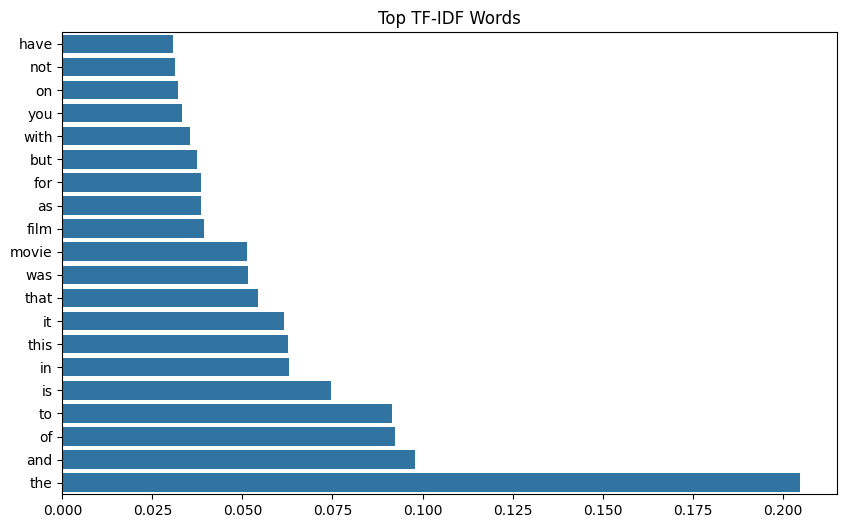

In [0]:
feature_names = tfidf_vectorizer.get_feature_names_out()
scores = np.mean(tfidf_matrix.toarray(), axis=0)

top_indices = scores.argsort()[-20:]

plt.figure(figsize=(10,6))
sns.barplot(x=scores[top_indices], y=feature_names[top_indices])
plt.title("Top TF-IDF Words")
plt.show()

In [0]:
avg_length = df['tokens'].apply(len).mean()

print("Average Tokens per Document:", avg_length)

# Most common words
from collections import Counter

all_words = [word for tokens in df['tokens'] for word in tokens]
common_words = Counter(all_words).most_common(10)

print("\nTop 10 Words:")
for word, freq in common_words:
    print(word, freq)

Average Tokens per Document: 114.4985

Top 10 Words:
movie 4266
film 3457
not 3015
one 2023
make 1875
like 1782
see 1724
bad 1599
get 1472
good 1357
